In [15]:
import numpy as np
import pymc as pm
import seaborn as sns
from scipy.stats import gamma, poisson
from empiricaldist import Pmf, Cdf
from utils import (
    pmf_from_dist, 
    set_pyplot_params, 
    decorate
)
sns.set_style('darkgrid')
set_pyplot_params()

## 19.2 Grid Approximation

In [5]:
alpha = 1.4
prior_dist = gamma(alpha)

lams = np.linspace(0, 10, 101)
prior_pmf = pmf_from_dist(prior_dist, lams)

data = 4
likelihood = poisson.pmf(data, lams)
posterior = prior_pmf * likelihood
posterior.normalize()

0.05015532557804499

## 19.3 Prior Predictive Distribution

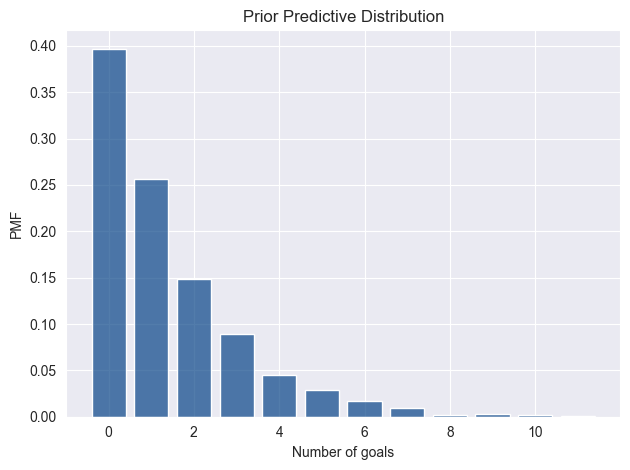

In [11]:
sample_prior = prior_dist.rvs(1000)
sample_prior_pred = poisson.rvs(sample_prior)
pmf_prior_pred = Pmf.from_seq(sample_prior_pred)

pmf_prior_pred.bar()
decorate(
    xlabel='Number of goals',
    ylabel='PMF',
    title='Prior Predictive Distribution'
)

## 19.4 Introducing PyMC

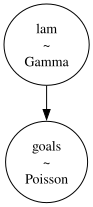

In [14]:
with pm.Model() as model:
    lam = pm.Gamma('lam', alpha=1.4, beta=1.0)
    goals = pm.Poisson('goals', lam)

pm.model_to_graphviz(model)

## 19.5 Sampling the Prior

In [16]:
with model:
    idata = pm.sample_prior_predictive(1000)


def get_values(array):
    return array.values.flatten()

sample_prior_pymc = get_values(idata.prior['lam'])

Sampling: [goals, lam]


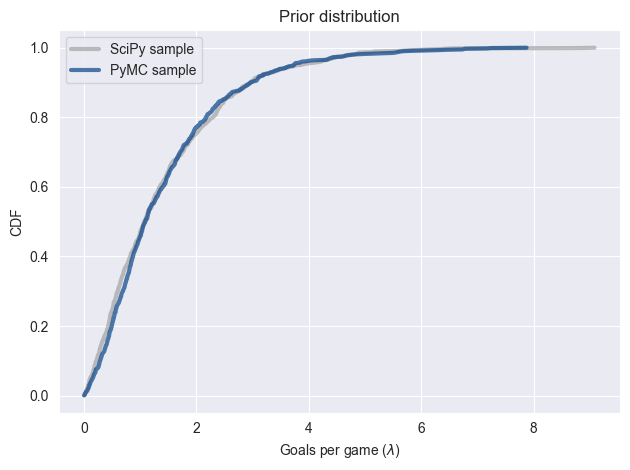

In [19]:
def plot_cdf(sample, **options):
    """Plot the CDF of a sample.

    sample: sequence of quantities
    """
    Cdf.from_seq(sample).plot(**options)


plot_cdf(sample_prior, label='SciPy sample', color='C5')
plot_cdf(sample_prior_pymc, label='PyMC sample', color='C0')
decorate(xlabel=r'Goals per game ($\lambda$)', ylabel='CDF', title='Prior distribution')

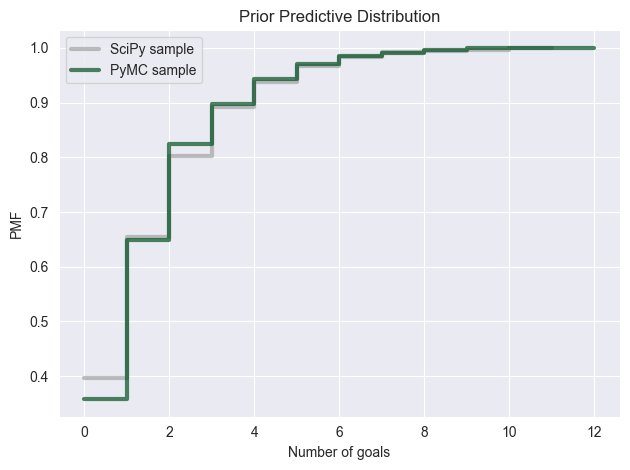

In [18]:
def plot_pred(sample, **options):
    Cdf.from_seq(sample).step(**options)


sample_prior_pred_pymc = get_values(idata.prior['goals'])

plot_pred(sample_prior_pred, label='SciPy sample', color='C5')
plot_pred(sample_prior_pred_pymc, label='PyMC sample',color='C13')
decorate(xlabel='Number of goals', ylabel='PMF', title='Prior Predictive Distribution')

## 19.6 When Do We Get to Inference?

In [22]:
with pm.Model() as model2:
    lam = pm.Gamma('lam', alpha=1.4, beta=1.0)
    goals = pm.Poisson('goals', lam, observed=4)

with model2:
    idata2 = pm.sample(500)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam]


Sampling 4 chains for 1_000 tune and 500 draw iterations (4_000 + 2_000 draws total) took 1 seconds.


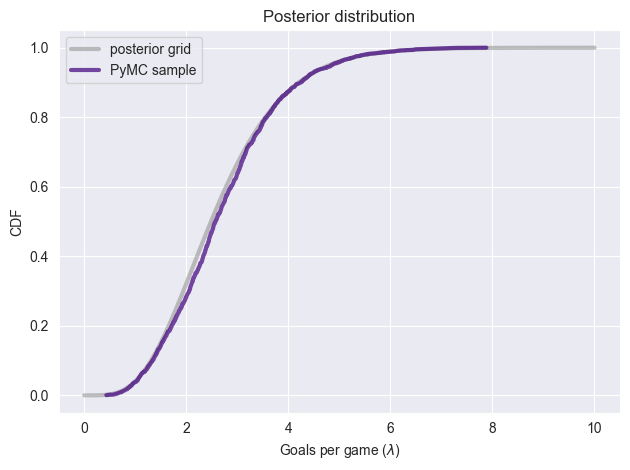

In [23]:
sample_post_pymc = get_values(idata2.posterior['lam'])

posterior.make_cdf().plot(label='posterior grid', color='C5')
plot_cdf(sample_post_pymc, label='PyMC sample', color='C4')

decorate(xlabel=r'Goals per game ($\lambda$)',ylabel='CDF', title='Posterior distribution')

## 19.7 Posterior Predictive Distribution

Sampling: [goals]


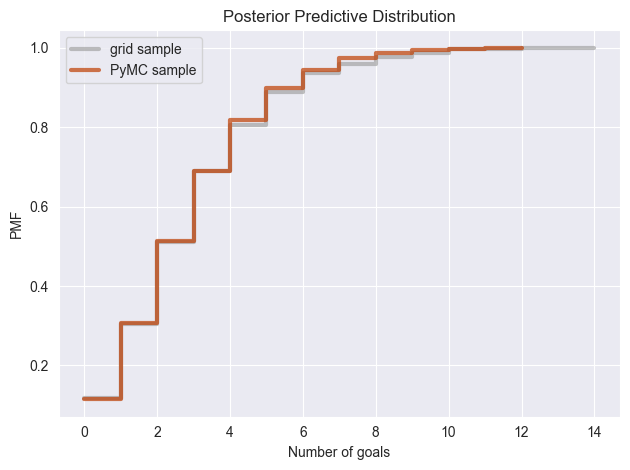

In [25]:
with model2:
    idata2_pred = pm.sample_posterior_predictive(idata2)

sample_post_pred_pymc = get_values(idata2_pred.posterior_predictive['goals'])

sample_post = posterior.sample(1000)
sample_post_pred = poisson(sample_post).rvs()

plot_pred(sample_post_pred, label='grid sample', color='C5')
plot_pred(sample_post_pred_pymc, label='PyMC sample', color='C12')

decorate(xlabel='Number of goals', ylabel='PMF',title='Posterior Predictive Distribution')